In [55]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates
from matplotlib import rcParams
import matplotlib as mpl
# plt.rc('text', usetex=True)
plt.style.use('fivethirtyeight')
rcParams['font.family'] = 'monospace'
rcParams['font.size'] = 15

In [2]:
def predict(time, y0, R0, Tinf = 2.9, Tinc = 5.2):
    def SEIR(funcs, t, R0, Tinf, Tinc):
        S, E, I, R = funcs
        beta = R0 / Tinf
        sigma = 1.0 / Tinc
        gamma = 1.0 / Tinf
        return [
            -beta * I * S / (S + E + I + R),
            beta * I * S / (S + E + I + R) - E * sigma,
            E * sigma - I * gamma,
            I * gamma
        ]
    sol = odeint(func=SEIR, y0=y0, t=time, args=(R0, Tinf, Tinc), hmax=0.01)
    return sol

def getTimeSince(interval, start = datetime.date(2020, 3, 1)):
    return [start + datetime.timedelta(days=i) for i in range(len(interval))]

In [88]:
interval1 = np.arange(35)
sol11 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=3.2)
sol12 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=3.5)
sol13 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=3.8)

time1 = getTimeSince(interval1, start = datetime.date(2020, 2, 27))

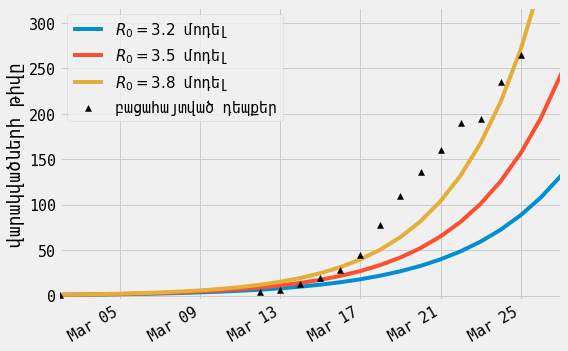

In [89]:
# real data
days = [1, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
cases = [1, 4, 6, 13, 20, 28, 45, 78, 110, 136, 160, 190, 194, 235, 265]
days = [datetime.date(2020, 3, 1) + datetime.timedelta(days=day) for day in days]

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)
fig.autofmt_xdate()

ax.plot(time1, sol11[:,2], label=r'$R_0=3.2$ մոդել');
ax.plot(time1, sol12[:,2], label=r'$R_0=3.5$ մոդել');
ax.plot(time1, sol13[:,2], label=r'$R_0=3.8$ մոդել');
ax.scatter(days, cases, c='k', marker='^', zorder=100, label='բացահայտված դեպքեր')

plt.legend();
ax.set_ylabel(r'վարակվածների թիվը')
ax.set_xlim(days[0], days[-1] + datetime.timedelta(days=2))
ax.set_ylim(-5, max(cases) * 1.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

In [42]:
def compare(R0, shift):
    days = [17, 18, 19, 20, 21, 22, 23, 24]
    cases = [78, 110, 136, 160, 190, 194, 235, 265]
    interval = np.arange(100)
    sol = predict(interval, [3e6, 0, 1, 0], R0)
    infected = sol[:,2]
    interval += shift
    cases_model = [infected[interval == day][0] for day in days]
    return np.sum((np.array(cases_model) - np.array(cases))**2 / np.array(cases_model))

In [45]:
R0_values = np.linspace(1.5, 5.5, 25)
shift_values = np.arange(-30, 0)

chisqr = [[compare(R0, shift) for R0 in R0_values] for shift in shift_values]

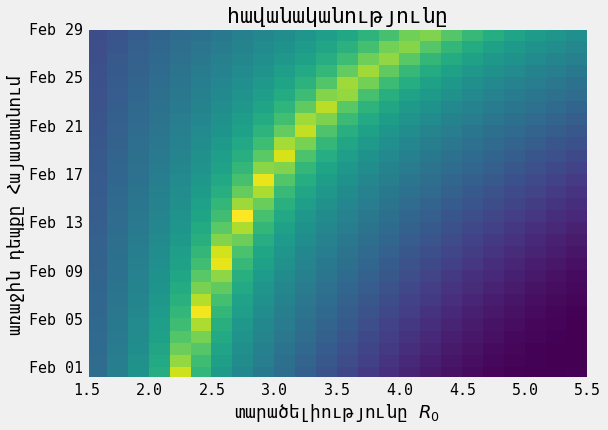

In [82]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

ax.pcolor(R0_values, [datetime.date(2020, 3, 1) + datetime.timedelta(days=int(shift)) for shift in shift_values], chisqr, cmap='viridis_r', norm=mpl.colors.LogNorm());
ax.set_title(r'հավանականությունը')
ax.set_ylabel(r'առաջին դեպքը Հայաստանում')
ax.set_xlabel(r'տարածելիությունը $R_0$');
ax.yaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

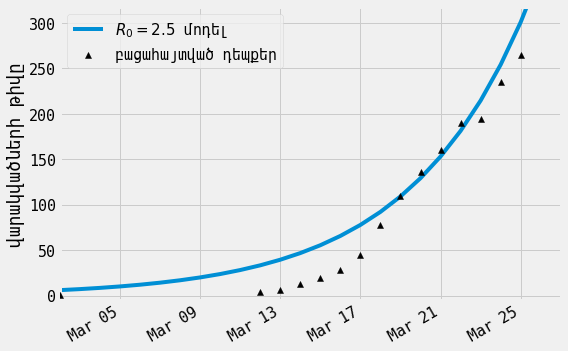

In [117]:
# real data
days = [1, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
cases = [1, 4, 6, 13, 20, 28, 45, 78, 110, 136, 160, 190, 194, 235, 265]
days = [datetime.date(2020, 3, 1) + datetime.timedelta(days=day) for day in days]

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)
fig.autofmt_xdate()

interval1 = np.arange(60)
time1 = getTimeSince(interval1, start = datetime.date(2020, 2, 15))
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
ax.plot(time1, sol1[:,2], label=r'$R_0=2.5$ մոդել');



ax.scatter(days, cases, c='k', marker='^', zorder=100, label='բացահայտված դեպքեր')

plt.legend();
ax.set_ylabel(r'վարակվածների թիվը')
ax.set_xlim(days[0], days[-1] + datetime.timedelta(days=2))
ax.set_ylim(-5, max(cases) * 1.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

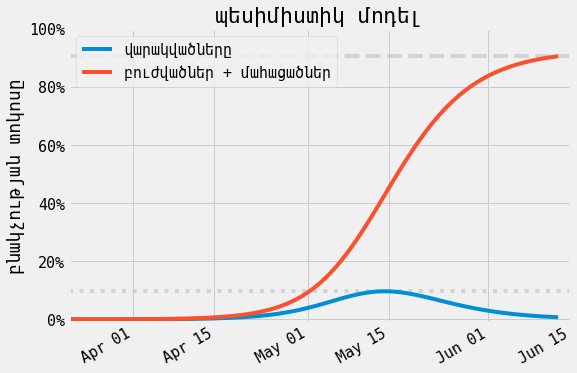

In [164]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)
fig.autofmt_xdate()

interval1 = np.arange(120)
time1 = getTimeSince(interval1, start = datetime.date(2020, 2, 15))
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
ax.plot(time1, sol1[:,2]/3e4, label='վարակվածները');
ax.plot(time1, sol1[:,3]/3e4, label='բուժվածներ + մահացածներ');
ax.axhline(sol1[:,3][-1]/3e4, c='lightgray', zorder=-1, ls='--')
ax.axhline(np.max(sol1[:,2])/3e4, c='lightgray', zorder=-1, ls=':')
plt.legend(loc='upper left');
ax.set_ylabel(r'բնակչության տոկոսը')
ax.set_xlim(time1[35], time1[-1] + datetime.timedelta(days=2))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100))
ax.set_title('պեսիմիստիկ մոդել')
ax.set_ylim(-1, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

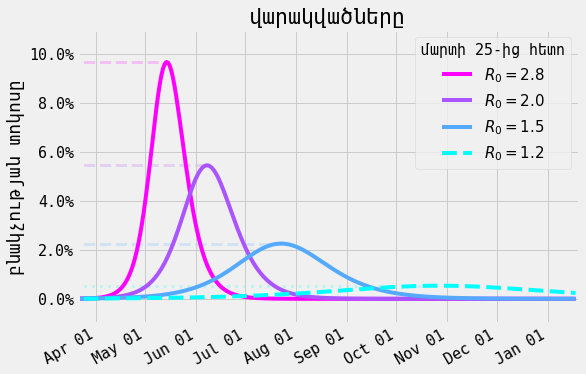

In [250]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)
fig.autofmt_xdate()

interval1 = np.arange(25+15)
interval2 = np.arange(300)

blues = [mpl.cm.cool(1-x) for x in np.linspace(0, 1, 4)]

R0 = 2.8
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,2]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[0]);
ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
        c=blues[0], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 2.0
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,2]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[1]);
ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
        c=blues[1], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 1.5
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,2]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[2]);
ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
        c=blues[2], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 1.2
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,2]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[3], ls='--');
ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
        c=blues[3], zorder=-1, ls=':', alpha=0.2, lw=3)

plt.legend(loc='upper right', title='մարտի 25-ից հետո');
ax.set_ylabel(r'բնակչության տոկոսը')
ax.set_xlim(time[35], time[-1] + datetime.timedelta(days=2))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100))
ax.set_title(r'վարակվածները')
ax.set_ylim(-1, 11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

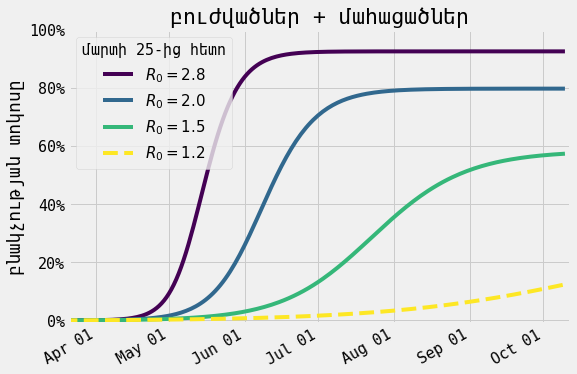

In [263]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)
fig.autofmt_xdate()

interval1 = np.arange(25+15)
interval2 = np.arange(200)

blues = [mpl.cm.viridis_r(1-x) for x in np.linspace(0, 1, 4)]

R0 = 2.8
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[0]);
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[0], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 2.0
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[1]);
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[1], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 1.5
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[2]);
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[2], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 1.2
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3]/3e4, label=r'$R_0={{{}}}$'.format(R0), c=blues[3], ls='--');
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[3], zorder=-1, ls=':', alpha=0.2, lw=3)

plt.legend(loc='upper left', title='մարտի 25-ից հետո');
ax.set_ylabel(r'բնակչության տոկոսը')
ax.set_xlim(time[35], time[-1] + datetime.timedelta(days=2))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100))
ax.set_title(r'բուժվածներ + մահացածներ')
ax.set_ylim(-1, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

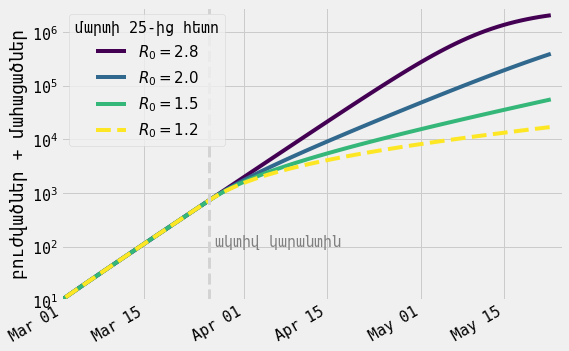

In [273]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)
fig.autofmt_xdate()

interval1 = np.arange(25+15)
interval2 = np.arange(60)

blues = [mpl.cm.viridis_r(1-x) for x in np.linspace(0, 1, 4)]

R0 = 2.8
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3], label=r'$R_0={{{}}}$'.format(R0), c=blues[0]);
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[0], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 2.0
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3], label=r'$R_0={{{}}}$'.format(R0), c=blues[1]);
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[1], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 1.5
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3], label=r'$R_0={{{}}}$'.format(R0), c=blues[2]);
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[2], zorder=-1, ls='--', alpha=0.2, lw=3)

R0 = 1.2
sol1 = predict(interval1, [3e6, 0, 1, 0], Tinf=2.9, R0=2.8, Tinc=5.2)
sol2 = predict(interval2, sol1[-1], Tinf=2.9, R0=R0, Tinc=5.2)[1:]
time = getTimeSince(np.concatenate((interval1, interval2[1:] + interval1[0])), start = datetime.date(2020, 2, 15))
sol = np.concatenate((sol1, sol2))
ax.plot(time, sol[:,3], label=r'$R_0={{{}}}$'.format(R0), c=blues[3], ls='--');
# ax.plot([time[0], time[np.argmax(sol[:,2])]], [np.max(sol[:,2])/3e4, np.max(sol[:,2])/3e4], 
#         c=blues[3], zorder=-1, ls=':', alpha=0.2, lw=3)

plt.legend(loc='upper left', title='մարտի 25-ից հետո');
ax.set_ylabel(r'բուժվածներ + մահացածներ')
ax.set_xlim(time[15], time[-1] + datetime.timedelta(days=2))
# ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100))
ax.set_ylim(10, 3e6)
ax.set_yscale('log')
ax.axvline(time[15+25], ls='--', c='lightgray', lw=3);
ax.text(time[15+26], 100, 'ակտիվ կարանտին', c='gray')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));